<a href="https://colab.research.google.com/github/springboardmentor12233a-tech/Palmistry-Tarot-Intelligence-Platform/blob/main/palm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle


In [ ]:
!mkdir -p ~/.kaggle
!cp "/content/kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d shyambhu/hands-and-palm-images-dataset

Dataset URL: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
License(s): DbCL-1.0
hands-and-palm-images-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q hands-and-palm-images-dataset.zip -d palm_dataset

replace palm_dataset/HandInfo.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!ls palm_dataset

HandInfo.csv  Hands


In [ ]:
# 1. Import all required libraries
import cv2
import mediapipe as mp
import os
import matplotlib.pyplot as plt
from glob import glob

# 2. Initialize MediaPipe Hands correctly
# Set static_image_mode to False for video streams or True for individual images
# For this task, we process individual images, so static_image_mode=True is appropriate.
# max_num_hands=1 as we expect one hand per image in a 'palm' dataset context.
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5, min_tracking_confidence=0.5)
mp_drawing = mp.solutions.drawing_utils

# 3. Load images from the Hands folder
# Assuming the dataset structure has images in 'palm_dataset/Hands'
image_dir = 'palm_dataset/Hands'
# Use glob to find all JPG images recursively within the Hands directory
image_paths = glob(os.path.join(image_dir, '**', '*.jpg'), recursive=True)

print(f"Found {len(image_paths)} images in '{image_dir}'.")

# Prepare to display sample images
num_samples_to_display = 5
displayed_count = 0

plt.figure(figsize=(15, 10)) # Set up a figure to display multiple images

for i, image_path in enumerate(image_paths):
    if displayed_count >= num_samples_to_display:
        break # Stop after displaying enough samples

    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not read image {image_path}. Skipping.")
        continue

    # Convert the BGR image to RGB as MediaPipe expects RGB input
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 4. Detect 21 hand landmarks
    results = hands.process(image_rgb)

    # Create a copy of the original image to draw on
    image_drawn = image_rgb.copy()

    # 5. Draw landmarks on sample images
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            # Draw the hand landmarks on the image_drawn
            mp_drawing.draw_landmarks(
                image_drawn, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        # 6. Display at least 5 images with detected landmarks
        plt.subplot(1, num_samples_to_display, displayed_count + 1) # Create subplot for current image
        plt.imshow(image_drawn)
        plt.title(f"Hand {displayed_count+1}")
        plt.axis('off') # Hide axes for cleaner display
        displayed_count += 1

    # else:
    #     print(f"No hand landmarks detected in {image_path}") # Uncomment for verbose output on images with no detections

plt.tight_layout()
plt.show()

# Release the MediaPipe Hands object
hands.close()

if displayed_count == 0:
    print("No hands were detected in the sampled images for display.")


ImportError: cannot import name 'runtime_version' from 'google.protobuf' (/usr/local/lib/python3.12/dist-packages/google/protobuf/__init__.py)

In [ ]:
# Fix for protobuf version incompatibility with MediaPipe
!pip install --upgrade protobuf==3.20.3

# IMPORTANT: After running this cell, please restart the Colab runtime
# (Runtime -> Restart runtime) and then re-run the previous cell (7e14d3e7).


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
google-cloud-datastore 2.25.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-monitoring 2.31.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-resource-manager 1.18.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
wandb 0.28.0 requires protobuf!=5.

In [ ]:
# First, uninstall potentially conflicting packages to clean up the environment.
# The -y flag confirms all prompts.
!pip uninstall -y mediapipe protobuf

# Now, install mediapipe. This should automatically fetch and install a protobuf
# version that is compatible with mediapipe.
# For mediapipe 0.10.14, this means protobuf in the range [4.25.3, 5).
!pip install mediapipe

# IMPORTANT: After running this cell, you MUST restart the Colab runtime
# (Runtime -> Restart runtime) and then re-run the cell with the MediaPipe import
# and landmark detection code (cell 7e14d3e7).


Found existing installation: mediapipe 0.10.35
Uninstalling mediapipe-0.10.35:
  Successfully uninstalled mediapipe-0.10.35
  Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl.metadata (9.8 kB)
Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl (12.4 MB)


In [ ]:
import mediapipe as mp

print("MediaPipe Version:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

MediaPipe Version: 0.10.35
Has solutions: False


In [ ]:
import mediapipe as mp

print(mp)
print(mp.__file__)
print(dir(mp))

<module 'mediapipe' from '/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py'>
/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


### Using MediaPipe Tasks Vision API for Hand Landmark Detection

Since `mp.solutions` is no longer available in your MediaPipe version, we will use the newer and more robust `MediaPipe Tasks Vision API`. This API requires downloading a pre-trained model for hand landmark detection.

In [ ]:
# 1. Download the pre-trained Hand Landmarker model
# This model detects the 21 hand landmarks.
!wget -q -O hand_landmarker.task - https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
print("Hand Landmarker model downloaded.")

# 2. Import necessary modules from MediaPipe Tasks
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 3. Configure the options for the HandLandmarker task
# We set the running mode to 'image' for processing static images
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)

# 4. Create a HandLandmarker object
# This object will be used to detect hand landmarks in images.
hand_landmarker = vision.HandLandmarker.create_from_options(options)
print("Hand Landmarker initialized successfully.")


Hand Landmarker model downloaded.
Hand Landmarker initialized successfully.


Now that the `HandLandmarker` is initialized, we can proceed with loading images from your `palm_dataset`, detecting the landmarks, drawing them, and displaying the results. This code is an adaptation of your previous request to use the new API.

Found 11076 images in 'palm_dataset/Hands'.


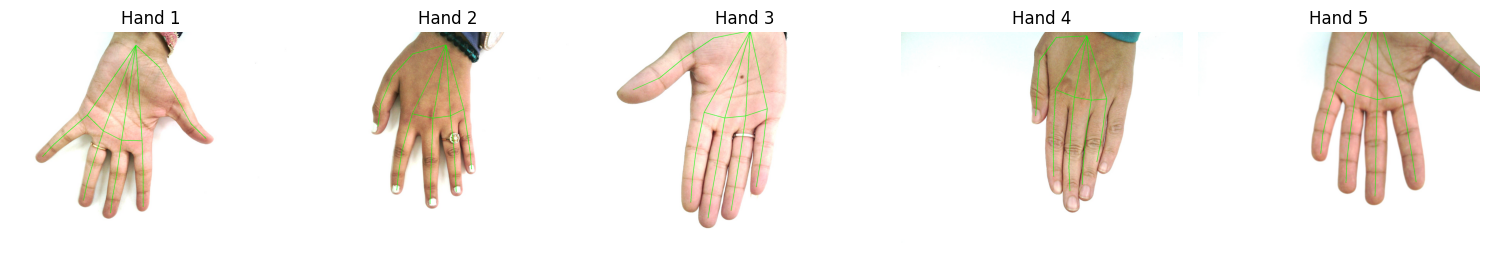

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
from glob import glob
import mediapipe as mp # Only need the top-level mediapipe for mp.Image, etc.

# Define hand connections based on MediaPipe's standard 21 hand landmarks
# These are tuples of (start_landmark_index, end_landmark_index)
HAND_CONNECTIONS = frozenset([
    (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # Index finger
    (0, 9), (9, 10), (10, 11), (11, 12),   # Middle finger
    (0, 13), (13, 14), (14, 15), (15, 16), # Ring finger
    (0, 17), (17, 18), (18, 19), (19, 20), # Pinky finger
    (5, 9), (9, 13), (13, 17)              # Palm base connections
])

def draw_landmarks_custom(image, landmarks, connections=None,
                          landmark_color=(255, 0, 0), landmark_radius=2,
                          connection_color=(0, 255, 0), connection_thickness=2):
    if not landmarks:
        return

    # Convert normalized landmarks to pixel coordinates
    h, w, _ = image.shape
    points = []
    for landmark in landmarks:
        cx, cy = int(landmark.x * w), int(landmark.y * h)
        points.append((cx, cy))
        cv2.circle(image, (cx, cy), landmark_radius, landmark_color, -1) # -1 for filled circle

    if connections:
        for connection in connections:
            start_idx, end_idx = connection
            if start_idx < len(points) and end_idx < len(points):
                start_point = points[start_idx]
                end_point = points[end_idx]
                cv2.line(image, start_point, end_point, connection_color, connection_thickness)

# Define the directory where your images are located
image_dir = 'palm_dataset/Hands'
# Use glob to find all JPG images recursively within the Hands directory
image_paths = glob(os.path.join(image_dir, '**', '*.jpg'), recursive=True)

print(f"Found {len(image_paths)} images in '{image_dir}'.")

# Prepare to display sample images
num_samples_to_display = 5
displayed_count = 0

plt.figure(figsize=(15, 10)) # Set up a figure to display multiple images

for i, image_path in enumerate(image_paths):
    if displayed_count >= num_samples_to_display:
        break # Stop after displaying enough samples

    # 5. Load image as MediaPipe Image format
    # MediaPipe Tasks APIs require images to be in their specific `mp.Image` format.
    # OpenCV's imread reads in BGR, so convert to RGB before creating mp.Image.
    cv_image = cv2.imread(image_path)
    if cv_image is None:
        print(f"Warning: Could not read image {image_path}. Skipping.")
        continue

    # Convert BGR to RGB
    rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
    # Corrected: Use mp.ImageFormat.SRGB for standard RGB images
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

    # 6. Detect hand landmarks
    # Perform landmark detection on the MediaPipe image.
    detection_result = hand_landmarker.detect(mp_image)

    # Create a copy of the original RGB image to draw on
    image_drawn = rgb_image.copy()

    # 7. Draw landmarks on sample images using the custom function
    if detection_result.hand_landmarks:
        for hand_landmarks_for_one_hand in detection_result.hand_landmarks:
            draw_landmarks_custom(
                image_drawn,
                hand_landmarks_for_one_hand, # Pass the list of NormalizedLandmark directly
                connections=HAND_CONNECTIONS, # Use our defined connections
                landmark_color=(255, 0, 0), # Red landmarks
                landmark_radius=2,
                connection_color=(0, 255, 0), # Green connections
                connection_thickness=2
            )

        # 8. Display at least 5 images with detected landmarks
        plt.subplot(1, num_samples_to_display, displayed_count + 1) # Create subplot for current image
        plt.imshow(image_drawn)
        plt.title(f"Hand {displayed_count+1}")
        plt.axis('off') # Hide axes for cleaner display
        displayed_count += 1

plt.tight_layout()
plt.show()

# Close the HandLandmarker to release resources
hand_landmarker.close()

if displayed_count == 0:
    print("No hands were detected in the sampled images for display.")

In [ ]:
import pandas as pd
import cv2
import os
import mediapipe as mp
from glob import glob
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Re-initialize the HandLandmarker as it was closed in the previous cell
# This model detects the 21 hand landmarks.
# We set the running mode to 'image' for processing static images
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
hand_landmarker = vision.HandLandmarker.create_from_options(options)
print("Hand Landmarker re-initialized for CSV generation.")

# Re-define image_dir and image_paths to ensure they are available
image_dir = 'palm_dataset/Hands'
image_paths = glob(os.path.join(image_dir, '**', '*.jpg'), recursive=True)

# List to store all landmark data for CSV
all_landmark_data = []
processed_images_count = 0

print(f"Starting landmark extraction for {len(image_paths)} images...")

for image_path in image_paths:
    # Load image as MediaPipe Image format
    cv_image = cv2.imread(image_path)
    if cv_image is None:
        print(f"Warning: Could not read image {image_path}. Skipping.")
        continue

    rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

    # Detect hand landmarks
    detection_result = hand_landmarker.detect(mp_image)

    # Skip if no hands are detected
    if not detection_result.hand_landmarks:
        continue

    # Assuming one hand per image, as per the HandLandmarkerOptions (num_hands=1)
    # Each `hand_landmarks_for_one_hand` is a list of NormalizedLandmark objects
    for hand_landmarks_for_one_hand in detection_result.hand_landmarks:
        row = {'filename': os.path.basename(image_path)}
        # Extract x, y, z coordinates for each of the 21 landmarks
        for i, landmark in enumerate(hand_landmarks_for_one_hand):
            row[f'landmark_{i}_x'] = landmark.x
            row[f'landmark_{i}_y'] = landmark.y
            row[f'landmark_{i}_z'] = landmark.z
        all_landmark_data.append(row)
        processed_images_count += 1

# Create a DataFrame from the collected data
df_landmarks = pd.DataFrame(all_landmark_data)

# Define the output CSV file path
output_csv_path = 'palm_landmarks.csv'

# Save the DataFrame to a CSV file
df_landmarks.to_csv(output_csv_path, index=False)

print(f"Finished processing. Total images with detected hands: {processed_images_count}")
print(f"Landmark data saved to: {output_csv_path}")

# Close the HandLandmarker to release resources after all processing is done
hand_landmarker.close()

Hand Landmarker re-initialized for CSV generation.
Starting landmark extraction for 11076 images...


KeyboardInterrupt: 

In [ ]:
# Re-running the cell to complete landmark extraction and CSV generation.
# This code will re-initialize the hand_landmarker and process all images again.

import pandas as pd
import cv2
import os
import mediapipe as mp
from glob import glob
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Re-initialize the HandLandmarker as it was closed in the previous cell
# This model detects the 21 hand landmarks.
# We set the running mode to 'image' for processing static images
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
hand_landmarker = vision.HandLandmarker.create_from_options(options)
print("Hand Landmarker re-initialized for CSV generation.")

# Re-define image_dir and image_paths to ensure they are available
image_dir = 'palm_dataset/Hands'
image_paths = glob(os.path.join(image_dir, '**', '*.jpg'), recursive=True)

# List to store all landmark data for CSV
all_landmark_data = []
processed_images_count = 0

print(f"Starting landmark extraction for {len(image_paths)} images...")

for image_path in image_paths:
    # Load image as MediaPipe Image format
    cv_image = cv2.imread(image_path)
    if cv_image is None:
        print(f"Warning: Could not read image {image_path}. Skipping.")
        continue

    rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

    # Detect hand landmarks
    detection_result = hand_landmarker.detect(mp_image)

    # Skip if no hands are detected
    if not detection_result.hand_landmarks:
        continue

    # Assuming one hand per image, as per the HandLandmarkerOptions (num_hands=1)
    # Each `hand_landmarks_for_one_hand` is a list of NormalizedLandmark objects
    for hand_landmarks_for_one_hand in detection_result.hand_landmarks:
        row = {'filename': os.path.basename(image_path)}
        # Extract x, y, z coordinates for each of the 21 landmarks
        for i, landmark in enumerate(hand_landmarks_for_one_hand):
            row[f'landmark_{i}_x'] = landmark.x
            row[f'landmark_{i}_y'] = landmark.y
            row[f'landmark_{i}_z'] = landmark.z
        all_landmark_data.append(row)
        processed_images_count += 1

# Create a DataFrame from the collected data
df_landmarks = pd.DataFrame(all_landmark_data)

# Define the output CSV file path
output_csv_path = 'palm_landmarks.csv'

# Save the DataFrame to a CSV file
df_landmarks.to_csv(output_csv_path, index=False)

print(f"Finished processing. Total images with detected hands: {processed_images_count}")
print(f"Landmark data saved to: {output_csv_path}")

# Close the HandLandmarker to release resources after all processing is done
hand_landmarker.close()

Hand Landmarker re-initialized for CSV generation.
Starting landmark extraction for 11076 images...
Finished processing. Total images with detected hands: 10587
Landmark data saved to: palm_landmarks.csv


In [ ]:
!ls

 hand_landmarker.task		    'kaggle (1).json'   palm_landmarks.csv
 hands-and-palm-images-dataset.zip   palm_dataset       sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("palm_landmarks.csv")

print("Shape:", df.shape)
df.head()

Shape: (10587, 64)


,filename,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,landmark_1_z,landmark_2_x,landmark_2_y,landmark_2_z,...,landmark_17_z,landmark_18_x,landmark_18_y,landmark_18_z,landmark_19_x,landmark_19_y,landmark_19_z,landmark_20_x,landmark_20_y,landmark_20_z
0,Hand_0006713.jpg,0.446425,0.067313,3.390738e-07,0.529503,0.170804,-0.038781,0.594287,0.320439,-0.061213,...,-0.059303,0.200323,0.482282,-0.081134,0.153223,0.537833,-0.098678,0.115707,0.591506,-0.112332
1,Hand_0008550.jpg,0.493003,0.065647,5.757094e-07,0.374893,0.108091,-0.027509,0.303270,0.212227,-0.037643,...,-0.026349,0.570745,0.503280,-0.046332,0.579751,0.584040,-0.061082,0.583519,0.650810,-0.069939
2,Hand_0005388.jpg,0.518669,-0.001768,7.152188e-07,0.388324,0.033114,-0.081453,0.283168,0.126770,-0.126241,...,-0.094847,0.565381,0.527472,-0.141219,0.553008,0.632258,-0.168803,0.540510,0.734739,-0.187547
3,Hand_0001373.jpg,0.659688,0.022962,7.413899e-07,0.550910,0.030700,-0.051852,0.491080,0.140483,-0.071174,...,-0.026719,0.716033,0.456541,-0.055447,0.705351,0.544398,-0.068811,0.694391,0.616374,-0.074998
4,Hand_0001816.jpg,0.637599,-0.091650,7.264052e-07,0.741078,-0.036485,-0.094898,0.835597,0.058013,-0.163316,...,-0.112957,0.459406,0.385679,-0.148316,0.442753,0.485662,-0.171906,0.435082,0.577154,-0.190076


# Tarot Dataset Processing

In [ ]:
import os

# Current directory ke files dekho
print(os.listdir())

['.config', 'hand_landmarker.task', 'palm_dataset', 'kaggle (1).json', 'hands-and-palm-images-dataset.zip', 'palm_landmarks.csv', 'sample_data']


In [ ]:
!ls

 hand_landmarker.task		    'kaggle (1).json'   palm_landmarks.csv
 hands-and-palm-images-dataset.zip   palm_dataset       sample_data


In [ ]:
!kaggle datasets download -d lsind18/tarot-json

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 4, in <module>
    from kaggle.api.kaggle_api_extended import KaggleApi
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 53, in <module>
    from google.protobuf import field_mask_pb2
ModuleNotFoundError: No module named 'google.protobuf'


In [ ]:
!ls

 hand_landmarker.task		    'kaggle (1).json'   palm_landmarks.csv
 hands-and-palm-images-dataset.zip   palm_dataset       sample_data


In [ ]:
!unzip "archive (2).zip" -d tarot_dataset

Archive:  archive (2).zip
  inflating: tarot_dataset/cards/c01.jpg  
  inflating: tarot_dataset/cards/c02.jpg  
  inflating: tarot_dataset/cards/c03.jpg  
  inflating: tarot_dataset/cards/c04.jpg  
  inflating: tarot_dataset/cards/c05.jpg  
  inflating: tarot_dataset/cards/c06.jpg  
  inflating: tarot_dataset/cards/c07.jpg  
  inflating: tarot_dataset/cards/c08.jpg  
  inflating: tarot_dataset/cards/c09.jpg  
  inflating: tarot_dataset/cards/c10.jpg  
  inflating: tarot_dataset/cards/c11.jpg  
  inflating: tarot_dataset/cards/c12.jpg  
  inflating: tarot_dataset/cards/c13.jpg  
  inflating: tarot_dataset/cards/c14.jpg  
  inflating: tarot_dataset/cards/m00.jpg  
  inflating: tarot_dataset/cards/m01.jpg  
  inflating: tarot_dataset/cards/m02.jpg  
  inflating: tarot_dataset/cards/m03.jpg  
  inflating: tarot_dataset/cards/m04.jpg  
  inflating: tarot_dataset/cards/m05.jpg  
  inflating: tarot_dataset/cards/m06.jpg  
  inflating: tarot_dataset/cards/m07.jpg  
  inflating: tarot_dataset/c

In [ ]:
!ls tarot_dataset
!ls tarot_dataset/cards | head

cards  tarot-images.json
c01.jpg
c02.jpg
c03.jpg
c04.jpg
c05.jpg
c06.jpg
c07.jpg
c08.jpg
c09.jpg
c10.jpg


In [ ]:
import json
import pandas as pd

with open("tarot_dataset/tarot-images.json", "r") as f:
    tarot = json.load(f)

print(type(tarot))
print("Total records:", len(tarot))

<class 'dict'>
Total records: 2


In [ ]:
print(tarot.keys())

dict_keys(['description', 'cards'])


In [ ]:
for key in tarot.keys():
    print(key)
    print(type(tarot[key]))
    if isinstance(tarot[key], list):
        print("Length:", len(tarot[key]))
    print("-"*40)

description
<class 'str'>
----------------------------------------
cards
<class 'list'>
Length: 78
----------------------------------------


In [ ]:
df = pd.DataFrame(tarot["cards"])

print("Shape:", df.shape)
df.head()

Shape: (78, 16)


,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]","{'light': ['Freeing yourself from limitation',...",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]","{'light': ['Taking appropriate action', 'Recei...",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",{'light': ['Listening to your feelings and int...,The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]","{'light': ['Nurturing yourself and others', 'B...",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]","{'light': ['Exercising authority', 'Defining l...",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,NaN,NaN


In [ ]:
print(df.columns.tolist())

['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'meanings', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask', 'Astrology', 'Affirmation']


Dataset Information


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   meanings            78 non-null     object
 8   Archetype           22 non-null     object
 9   Hebrew Alphabet     22 non-null     object
 10  Numerology          62 non-null     object
 11  Elemental           38 non-null     object
 12  Mythical/Spiritual  22 non-null     object
 13  Questions to Ask    78 non-null     object
 14  Astrology           40 non-null     object
 15  Affirmation         56 non-null     object
dtypes: object(16)
memory usage: 

Missing Values Check

In [ ]:
print(df.isnull().sum())

name                   0
number                 0
arcana                 0
suit                   0
img                    0
fortune_telling        0
keywords               0
meanings               0
Archetype             56
Hebrew Alphabet       56
Numerology            16
Elemental             40
Mythical/Spiritual    56
Questions to Ask       0
Astrology             38
Affirmation           22
dtype: int64


Arcana Distribution

In [ ]:
print(df["arcana"].value_counts())

arcana
Minor Arcana    56
Major Arcana    22
Name: count, dtype: int64


Suit Distribution

In [ ]:
print(df["suit"].value_counts())

suit
Trump        22
Cups         14
Swords       14
Wands        14
Pentacles    14
Name: count, dtype: int64


Sample Card Details

In [ ]:
print(df.loc[0])

name                                                           The Fool
number                                                                0
arcana                                                     Major Arcana
suit                                                              Trump
img                                                             m00.jpg
fortune_telling       [Watch for new projects and new beginnings, Pr...
keywords                      [freedom, faith, inexperience, innocence]
meanings              {'light': ['Freeing yourself from limitation',...
Archetype                                             The Divine Madman
Hebrew Alphabet                                              Aleph/Ox/1
Numerology                            0 (off the scale; pure potential)
Elemental                                                           Air
Mythical/Spiritual    Adam before the fall. Christ as a wandering ho...
Questions to Ask      [What would I do if I felt free to take a 

Save Clean CSV

In [ ]:
df.to_csv("tarot_cards.csv", index=False)

print("CSV Saved Successfully!")

CSV Saved Successfully!


In [ ]:
import pandas as pd

# Palm dataset load
palm_df = pd.read_csv("palm_landmarks.csv")

print(palm_df.shape)

palm_df.head()

(10587, 64)


,filename,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,landmark_1_z,landmark_2_x,landmark_2_y,landmark_2_z,...,landmark_17_z,landmark_18_x,landmark_18_y,landmark_18_z,landmark_19_x,landmark_19_y,landmark_19_z,landmark_20_x,landmark_20_y,landmark_20_z
0,Hand_0006713.jpg,0.446425,0.067313,3.390738e-07,0.529503,0.170804,-0.038781,0.594287,0.320439,-0.061213,...,-0.059303,0.200323,0.482282,-0.081134,0.153223,0.537833,-0.098678,0.115707,0.591506,-0.112332
1,Hand_0008550.jpg,0.493003,0.065647,5.757094e-07,0.374893,0.108091,-0.027509,0.303270,0.212227,-0.037643,...,-0.026349,0.570745,0.503280,-0.046332,0.579751,0.584040,-0.061082,0.583519,0.650810,-0.069939
2,Hand_0005388.jpg,0.518669,-0.001768,7.152188e-07,0.388324,0.033114,-0.081453,0.283168,0.126770,-0.126241,...,-0.094847,0.565381,0.527472,-0.141219,0.553008,0.632258,-0.168803,0.540510,0.734739,-0.187547
3,Hand_0001373.jpg,0.659688,0.022962,7.413899e-07,0.550910,0.030700,-0.051852,0.491080,0.140483,-0.071174,...,-0.026719,0.716033,0.456541,-0.055447,0.705351,0.544398,-0.068811,0.694391,0.616374,-0.074998
4,Hand_0001816.jpg,0.637599,-0.091650,7.264052e-07,0.741078,-0.036485,-0.094898,0.835597,0.058013,-0.163316,...,-0.112957,0.459406,0.385679,-0.148316,0.442753,0.485662,-0.171906,0.435082,0.577154,-0.190076


In [ ]:
import glob

images = glob.glob("palm_dataset/Hands/**/*.jpg", recursive=True)

print("Total Images:", len(images))
print("First Image:", images[0])

Total Images: 11076
First Image: palm_dataset/Hands/Hands/Hand_0006713.jpg


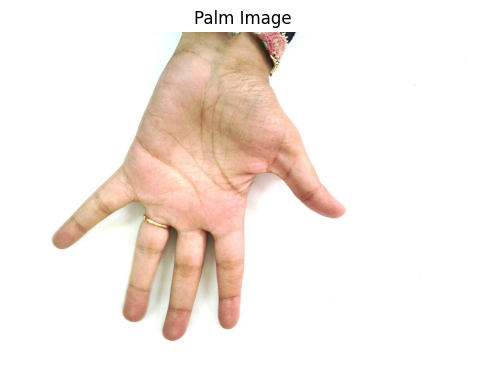

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load first palm image
img = cv2.imread(images[0])

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Palm Image")
plt.axis("off")
plt.show()

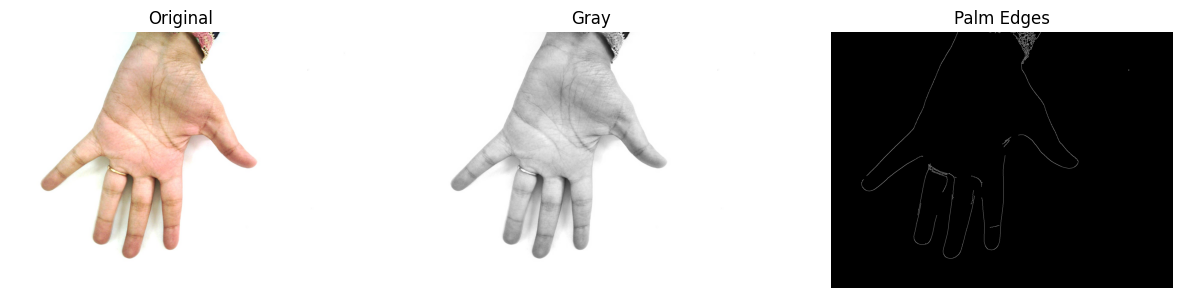

In [ ]:
# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Detect Edges
edges = cv2.Canny(blur, 50, 150)

# Display Results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap="gray")
plt.title("Palm Edges")
plt.axis("off")

plt.show()

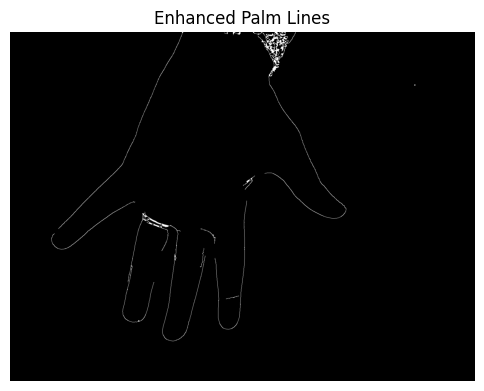

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Morphological Closing to connect broken edges
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
enhanced = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(6,6))
plt.imshow(enhanced, cmap="gray")
plt.title("Enhanced Palm Lines")
plt.axis("off")
plt.show()

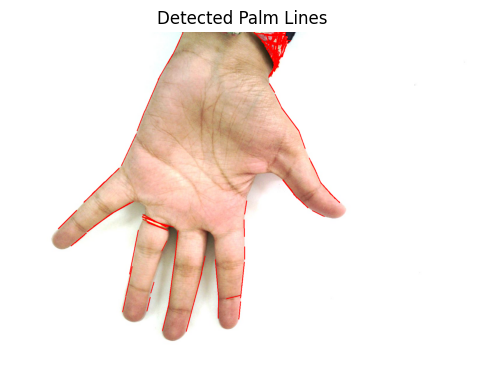

In [ ]:
import numpy as np

# Copy original image
line_img = img_rgb.copy()

# Detect lines
lines = cv2.HoughLinesP(
    enhanced,
    rho=1,
    theta=np.pi/180,
    threshold=40,
    minLineLength=30,
    maxLineGap=10
)

# Draw detected lines
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (255,0,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(line_img)
plt.title("Detected Palm Lines")
plt.axis("off")
plt.show()

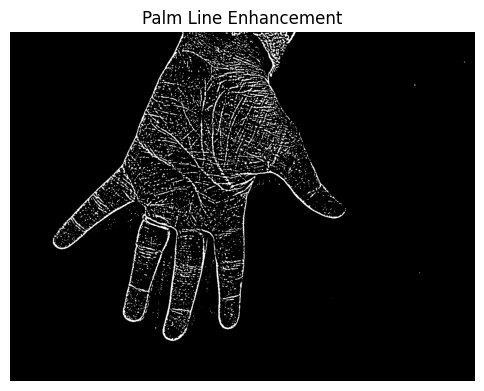

In [ ]:
import cv2
import matplotlib.pyplot as plt

# CLAHE for better contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray2 = clahe.apply(gray)

# Gaussian Blur
blur = cv2.GaussianBlur(gray2, (5,5), 0)

# Adaptive Threshold
thresh = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15,
    5
)

plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap="gray")
plt.title("Palm Line Enhancement")
plt.axis("off")
plt.show()

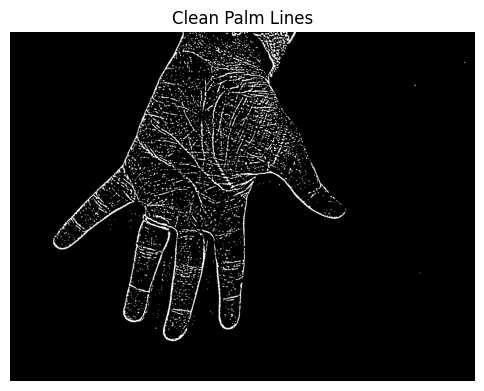

In [ ]:
# Morphological Opening
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(6,6))
plt.imshow(clean, cmap="gray")
plt.title("Clean Palm Lines")
plt.axis("off")
plt.show()

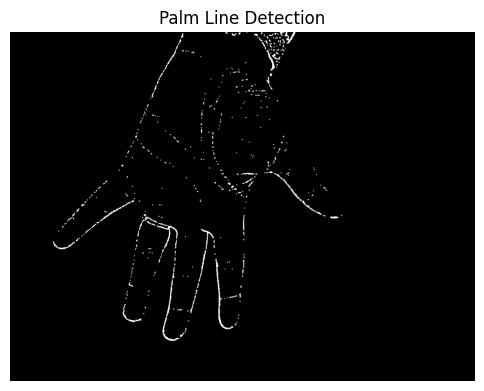

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Adaptive Threshold
thresh = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    8
)

# Remove small noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Slightly connect palm lines
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(6,6))
plt.imshow(clean, cmap="gray")
plt.title("Palm Line Detection")
plt.axis("off")
plt.show()

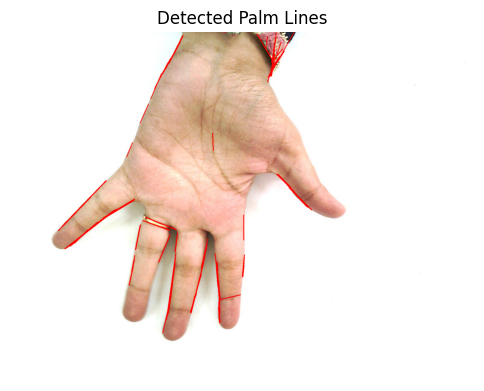

In [ ]:
import numpy as np

lines = cv2.HoughLinesP(
    clean,
    1,
    np.pi/180,
    threshold=80,
    minLineLength=40,
    maxLineGap=15
)

line_img = img_rgb.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (255,0,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(line_img)
plt.title("Detected Palm Lines")
plt.axis("off")
plt.show()

In [ ]:
import pandas as pd

# Load landmark dataset
df = pd.read_csv("palm_landmarks.csv")

print("Dataset Shape:", df.shape)
print()

# Remove filename column
X = df.drop("filename", axis=1)

print("Feature Shape:", X.shape)

X.head()

Dataset Shape: (10587, 64)

Feature Shape: (10587, 63)


,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,landmark_1_z,landmark_2_x,landmark_2_y,landmark_2_z,landmark_3_x,...,landmark_17_z,landmark_18_x,landmark_18_y,landmark_18_z,landmark_19_x,landmark_19_y,landmark_19_z,landmark_20_x,landmark_20_y,landmark_20_z
0,0.446425,0.067313,3.390738e-07,0.529503,0.170804,-0.038781,0.594287,0.320439,-0.061213,0.641577,...,-0.059303,0.200323,0.482282,-0.081134,0.153223,0.537833,-0.098678,0.115707,0.591506,-0.112332
1,0.493003,0.065647,5.757094e-07,0.374893,0.108091,-0.027509,0.303270,0.212227,-0.037643,0.261383,...,-0.026349,0.570745,0.503280,-0.046332,0.579751,0.584040,-0.061082,0.583519,0.650810,-0.069939
2,0.518669,-0.001768,7.152188e-07,0.388324,0.033114,-0.081453,0.283168,0.126770,-0.126241,0.196327,...,-0.094847,0.565381,0.527472,-0.141219,0.553008,0.632258,-0.168803,0.540510,0.734739,-0.187547
3,0.659688,0.022962,7.413899e-07,0.550910,0.030700,-0.051852,0.491080,0.140483,-0.071174,0.482520,...,-0.026719,0.716033,0.456541,-0.055447,0.705351,0.544398,-0.068811,0.694391,0.616374,-0.074998
4,0.637599,-0.091650,7.264052e-07,0.741078,-0.036485,-0.094898,0.835597,0.058013,-0.163316,0.936976,...,-0.112957,0.459406,0.385679,-0.148316,0.442753,0.485662,-0.171906,0.435082,0.577154,-0.190076


In [ ]:
from sklearn.preprocessing import StandardScaler

# Convert to float
X = X.astype("float32")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (10587, 63)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

PCA Shape: (10587, 2)


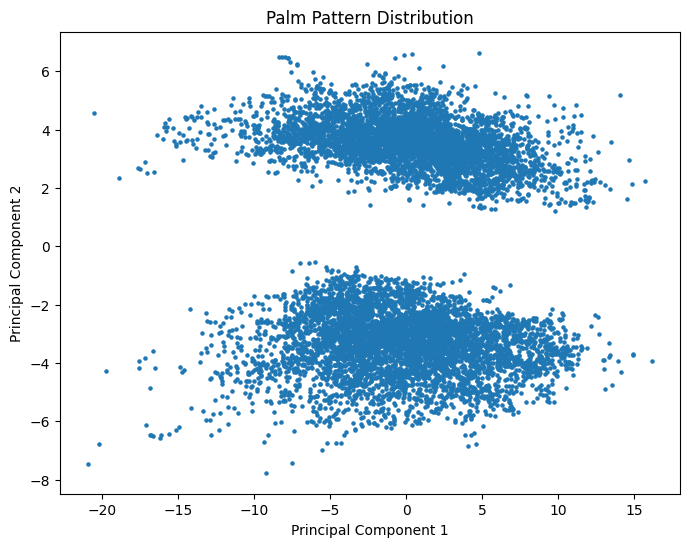

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=5
)

plt.title("Palm Pattern Distribution")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Create KMeans model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Train model
kmeans.fit(X_scaled)

print("KMeans Model Trained Successfully!")

KMeans Model Trained Successfully!


In [ ]:
clusters = kmeans.predict(X_scaled)

print(clusters[:20])

[4 1 0 2 0 1 3 3 1 3 4 1 0 1 0 3 4 1 4 3]


In [ ]:
palm_df["Cluster"] = clusters

print(palm_df["Cluster"].value_counts())

Cluster
4    2540
2    2434
3    2347
1    2256
0    1010
Name: count, dtype: int64


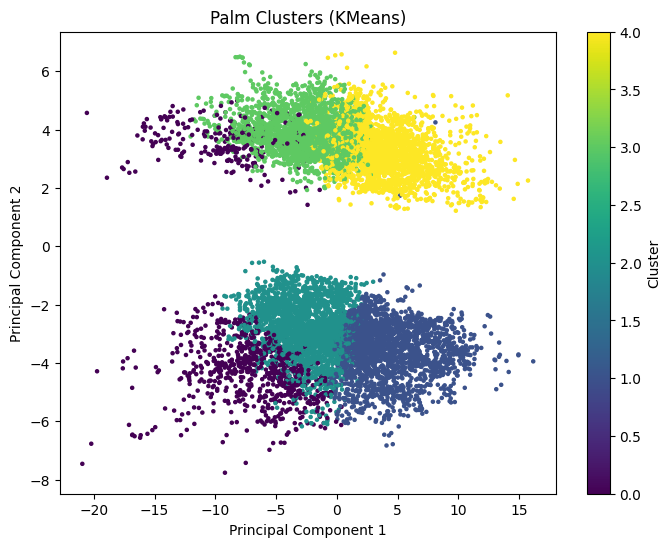

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=5
)

plt.title("Palm Clusters (KMeans)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
print(palm_df["Cluster"].value_counts().sort_index())

Cluster
0    1010
1    2256
2    2434
3    2347
4    2540
Name: count, dtype: int64


In [ ]:
cluster_summary = palm_df.groupby("Cluster").mean(numeric_only=True)

print(cluster_summary)

         landmark_0_x  landmark_0_y  landmark_0_z  landmark_1_x  landmark_1_y  \
Cluster                                                                         
0            0.581164     -0.009246  6.940628e-07      0.510318      0.031128   
1            0.539672      0.075096  4.157670e-07      0.416259      0.129750   
2            0.572745      0.002696  4.686823e-07      0.456926      0.041380   
3            0.525816     -0.038000  1.807875e-07      0.628160      0.057591   
4            0.556507      0.050879  1.586875e-07      0.661307      0.159532   

         landmark_1_z  landmark_2_x  landmark_2_y  landmark_2_z  landmark_3_x  \
Cluster                                                                         
0           -0.046249      0.454027      0.130968     -0.082023      0.412493   
1           -0.033923      0.335599      0.252493     -0.041498      0.293224   
2           -0.033249      0.376844      0.140565     -0.049312      0.328850   
3           -0.029764      

In [ ]:
cluster_summary.to_csv("palm_cluster_summary.csv")

print("Cluster Summary Saved Successfully!")

Cluster Summary Saved Successfully!


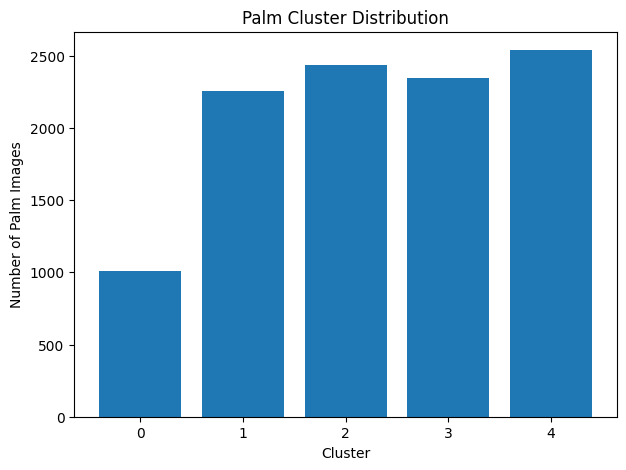

In [ ]:
import matplotlib.pyplot as plt

cluster_counts = palm_df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Palm Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Palm Images")

plt.show()